In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.insert(1,"../src/")

In [3]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

import acoustic_inversion as ai

from utilities import scramble_nums

In [4]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [5]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [250, 400]

In [6]:
with np.load("../data/output/components_arrival_times.npz", allow_pickle=True ) as file1:
    data_components = dict(mode_nos = file1['mode_nos'].squeeze(), peaks_coordinates=file1['peaks_coordinates'])
data_components['mode_nos'] = data_components['mode_nos'] - 1

In [83]:
# in this block, we introduce some perturbation to the mode numbers

modes = data_components['mode_nos']
#perturbed_modes = scramble_nums(data_components['mode_nos'])
perturbed_modes = np.copy(modes)
perturbed_modes[2:] = perturbed_modes[2:] + 1
#perturbed_modes[0] = 1
#perturbed_modes[1] = 0

In [84]:
np.array([modes, perturbed_modes])

array([[ 0,  1,  4,  6,  7,  8,  9, 13, 15],
       [ 0,  1,  5,  7,  8,  9, 10, 14, 16]])

In [85]:
replicas = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze().transpose([1,0,2])
#Vg = Vg[data_components['mode_nos'].squeeze()]
receiver_range = replicas['range'][0,0]*1e3

nmodes, nspeed, nfreq = Vg.shape

In [86]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [87]:
arrival_times_replica = receiver_range/Vg[...,f_mask]

In [88]:
arrival_times_components = ai.arrival_times_from_peaks(data_components['peaks_coordinates'], regression_f)

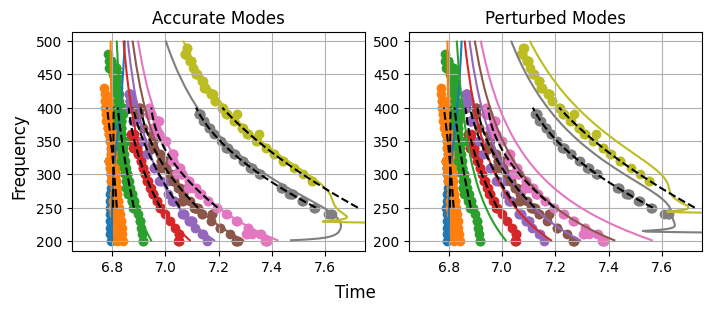

In [89]:
fig, (ax_comp, ax_pert) = plt.subplots(1, 2, layout="constrained")

for p in data_components['peaks_coordinates']:
    ax_comp.scatter(p[:,1], p[:,0])
    
ax_comp.plot(receiver_range/Vg[c==TRUE_SOUNDSPEED, modes,:].T, f_Vg)
ax_comp.set_prop_cycle(None)
ax_comp.plot(arrival_times_components.T, regression_f, ls='--', c='k')

ax_comp.set_xlim([6.65, 7.75])

ax_comp.grid()

ax_comp.set_title("Accurate Modes")

for p in data_components['peaks_coordinates']:
    ax_pert.scatter(p[:,1], p[:,0])
    
ax_pert.plot(receiver_range/Vg[c==TRUE_SOUNDSPEED, perturbed_modes,:].T, f_Vg)
ax_pert.set_prop_cycle(None)
ax_pert.plot(arrival_times_components.T, regression_f, ls='--', c='k')

ax_pert.set_xlim([6.65, 7.75])

ax_pert.grid()

ax_pert.set_title("Perturbed Modes")

fig.supylabel("Frequency")
fig.supxlabel("Time")

fig.set_size_inches([7, 3])

In [90]:
fig.savefig("../data/output/mode_curves.png", dpi=600)

In [91]:
l_comp = ai.AcousticInversionLikelihood(arrival_times_components)

[[6.80358315 6.80358784 6.80359264 ... 6.80545704 6.80547778 6.80549863]
 [6.81733309 6.81716107 6.81698808 ... 6.78125163 6.78093509 6.78061757]
 [6.88171346 6.88117768 6.88064362 ... 6.82116157 6.8208808  6.82060176]
 ...
 [7.19631792 7.19322862 7.19015851 ... 6.94779506 6.94754513 6.94731438]
 [7.56577999 7.56100793 7.5562596  ... 7.11765214 7.11639215 7.11515588]
 [7.72371666 7.71919951 7.71469741 ... 7.21873612 7.21644423 7.21416739]]


## Likelihood

In [92]:
normalize = lambda x: x/np.sum(x)

In [93]:
lk_comp = l_comp.likelihood(arrival_times_replica[:, modes], 1e0)
pert_lk_comp = l_comp.likelihood(arrival_times_replica[:, perturbed_modes], 1e0)

In [94]:
lk_comp = normalize(lk_comp)
pert_lk_comp = normalize(pert_lk_comp)

In [95]:
pmf_mean = lambda x, p: np.sum(x*p)
pmf_var = lambda x, p: pmf_mean(x**2, p) - pmf_mean(x,p)**2

In [96]:
var = pmf_var(c, lk_comp)

In [97]:
pert_var = pmf_var(c, pert_lk_comp)

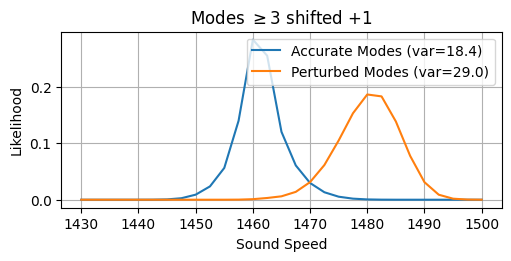

In [99]:
fig, ax = plt.subplots(layout="constrained")

ax.plot(c, lk_comp)
ax.plot(c, pert_lk_comp)
ax.grid()

ax.legend([f"Accurate Modes (var={var:1.1f})", f"Perturbed Modes (var={pert_var:1.1f})"])

ax.set_xlabel("Sound Speed")
ax.set_ylabel("Likelihood")
ax.set_title("Modes $\\geq 3$ shifted +1")
# ax.set_title("Modes 1 and 2 swapped")

fig.set_size_inches([5, 2.5])

In [100]:
fig.savefig("../data/output/likelihood_shiftmodes.png", dpi=600)